# Quantum Dementia Classifier — Data Exploration
## OASIS-2 Longitudinal MRI Dataset (150 subjects, 373 sessions)


# Imports & load

In [170]:

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

with zipfile.ZipFile("dementia_dataset.zip") as z:
    csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
    df = pd.read_csv(z.open(csv_name))

    
# Rename some feature  " "M/F": "Sex"
#df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df = df.rename(columns={"M/F": "Sex"})
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,Sex,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [171]:
#Shape & dtypes
print(df.shape)
print(df.dtypes)

(373, 15)
Subject ID     object
MRI ID         object
Group          object
Visit           int64
MR Delay        int64
Sex            object
Hand           object
Age             int64
EDUC            int64
SES           float64
MMSE          float64
CDR           float64
eTIV            int64
nWBV          float64
ASF           float64
dtype: object


In [172]:
# Check for Missing values
print(df.isnull().sum()) 


Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
Sex            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64


In [173]:
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,Sex,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [174]:

# Basic cleaning
#df = df.drop(columns=["Hand"])                          # all right-handed
df = df.rename(columns={"M/F": "Sex"})
df["Sex_enc"] = (df["Sex"].str.upper() == "M").astype(int)




df["SES"]  = df.groupby("Group")["SES"].transform(lambda x: x.fillna(x.median()))
df["MMSE"] = df.groupby("Group")["MMSE"].transform(lambda x: x.fillna(x.median()))
df["Label"] = df["Group"].map({"Nondemented": 0, "Demented": 1, "Converted": 1})


df.isnull().sum()

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
Sex           0
Hand          0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
Sex_enc       0
Label         0
dtype: int64

In [156]:
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,Sex,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Sex_enc,Label
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883,1,0
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876,1,0
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,3.0,23.0,0.5,1678,0.736,1.046,1,1
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,3.0,28.0,0.5,1738,0.713,1.010,1,1
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,3.0,22.0,0.5,1698,0.701,1.034,1,1


In [175]:
# Class distribution
df.drop_duplicates("Subject ID")["Group"].value_counts()

Group
Nondemented    72
Demented       64
Converted      14
Name: count, dtype: int64

In [176]:
# Summary stats by group (baseline sessions only)
baseline = df[df["Visit"] == 1].copy()
baseline.groupby("Group")[["Age", "EDUC", "SES", "MMSE"]].agg(["mean", "std"]).round(2)


Age         EDUC         SES         MMSE      
              mean   std   mean   std  mean   std   mean   std
Group                                                         
Converted    77.07  7.69  15.14  2.57  1.86  1.03  29.36  0.93
Demented     75.11  6.74  13.69  2.92  2.78  1.11  25.33  3.32
Nondemented  75.43  8.23  15.17  2.73  2.42  1.06  29.19  0.85

In [161]:
baseline

,Subject ID,MRI ID,Group,Visit,MR Delay,Sex,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Sex_enc,Label
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883,1,0
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,3.0,23.0,0.5,1678,0.736,1.046,1,1
5,OAS2_0004,OAS2_0004_MR1,Nondemented,1,0,F,R,88,18,3.0,28.0,0.0,1215,0.710,1.444,0,0
7,OAS2_0005,OAS2_0005_MR1,Nondemented,1,0,M,R,80,12,4.0,28.0,0.0,1689,0.712,1.039,1,0
10,OAS2_0007,OAS2_0007_MR1,Demented,1,0,M,R,71,16,3.0,28.0,0.5,1357,0.748,1.293,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,OAS2_0182,OAS2_0182_MR1,Demented,1,0,M,R,73,12,3.0,23.0,0.5,1661,0.698,1.056,1,1
361,OAS2_0183,OAS2_0183_MR1,Nondemented,1,0,F,R,66,13,2.0,30.0,0.0,1495,0.746,1.174,0,0
365,OAS2_0184,OAS2_0184_MR1,Demented,1,0,F,R,72,16,3.0,24.0,0.5,1354,0.733,1.296,0,1
367,OAS2_0185,OAS2_0185_MR1,Demented,1,0,M,R,80,16,1.0,28.0,0.5,1704,0.711,1.030,1,1


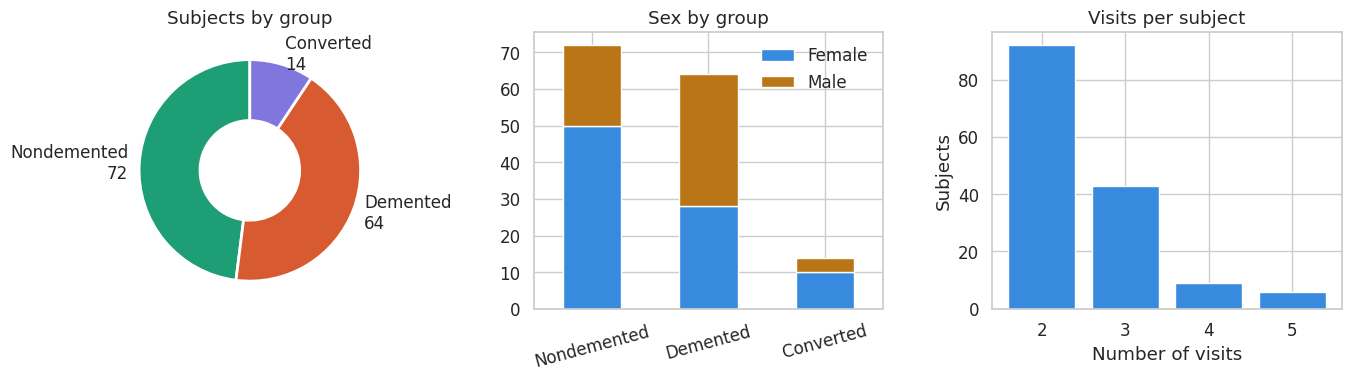

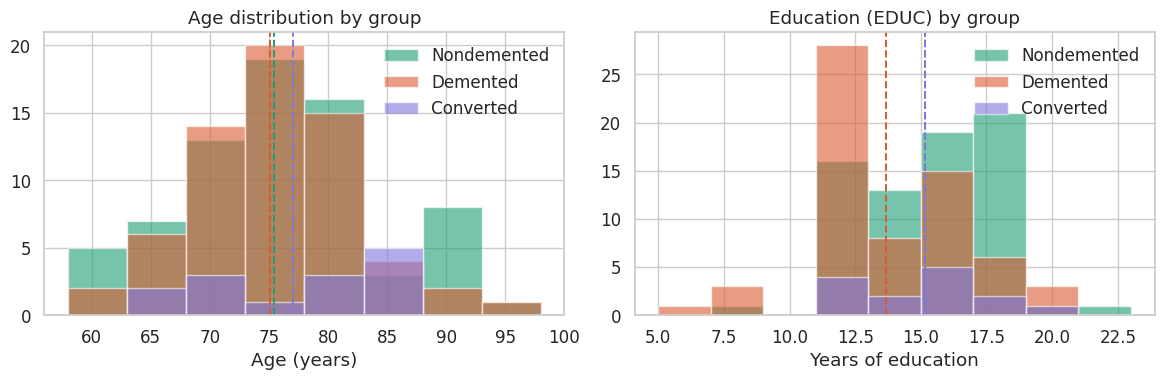

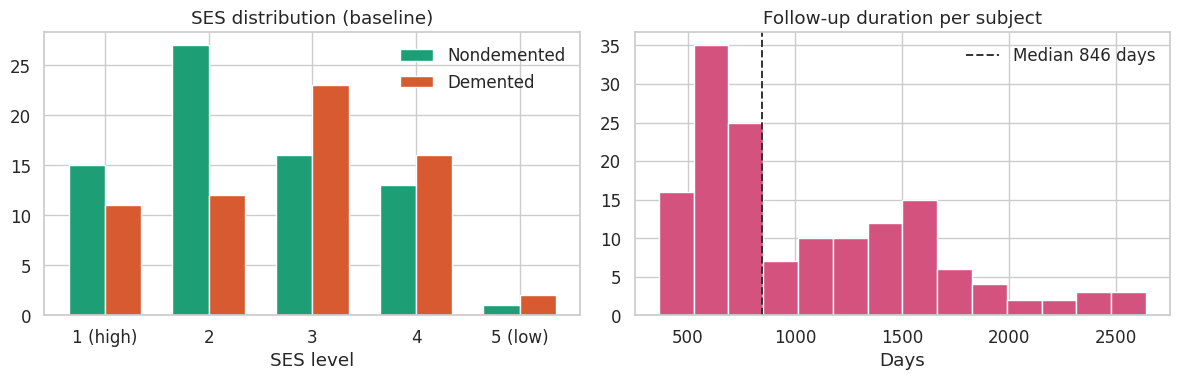

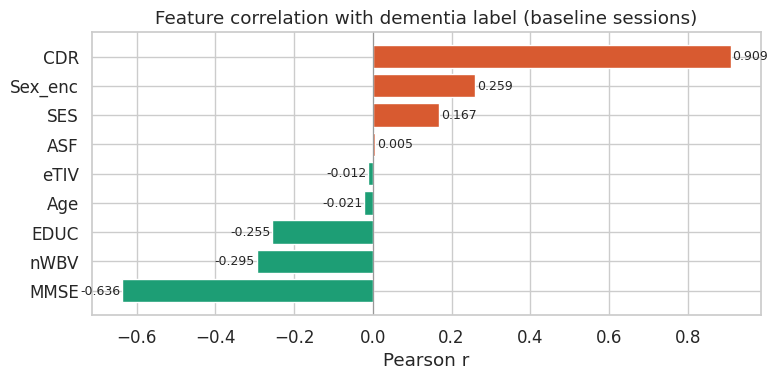

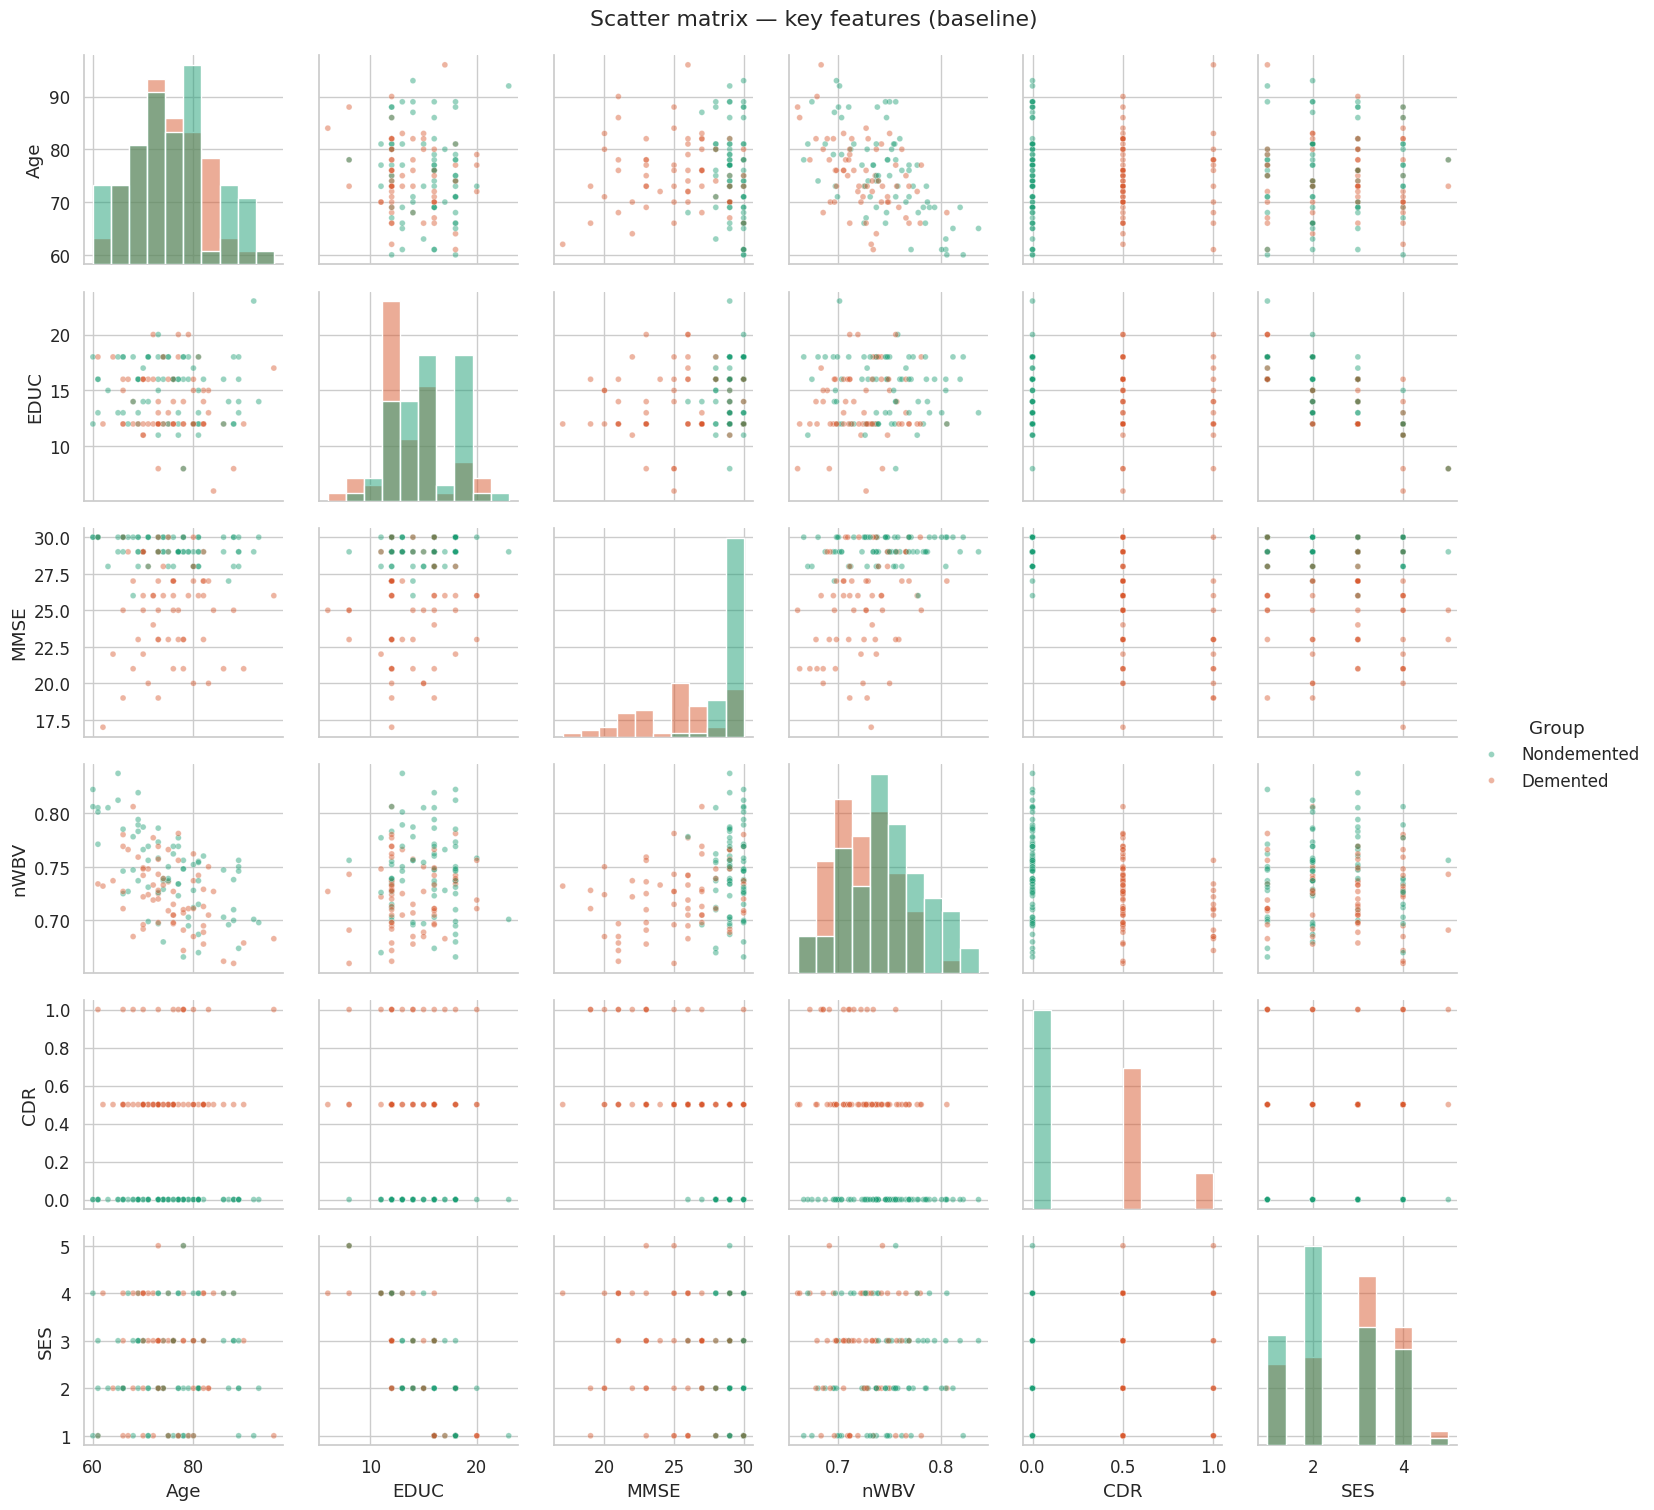

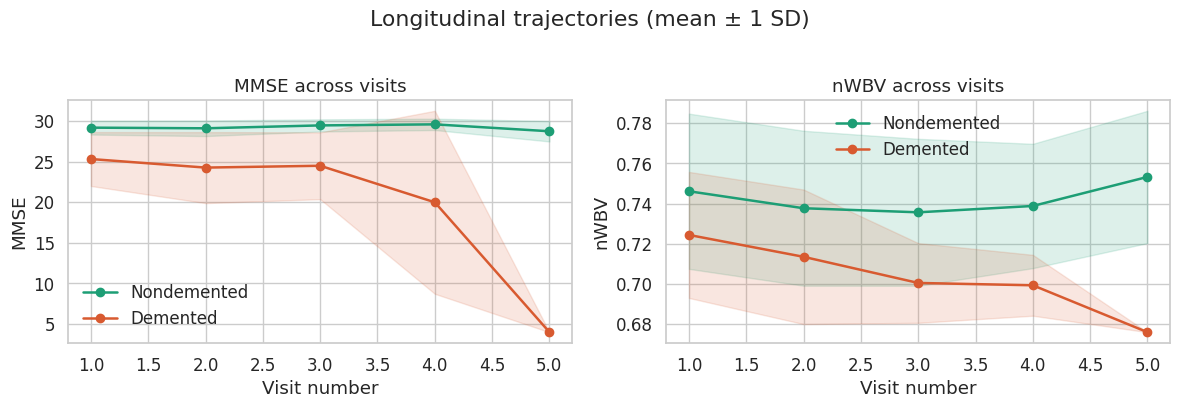

In [147]:

# 7 — Figure 1: class donut + sex bar + visit count
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
COLORS = {"Nondemented": "#1D9E75", "Demented": "#D85A30", "Converted": "#7F77DD"}

# Donut
subj = df.drop_duplicates("Subject ID")
counts = subj["Group"].value_counts().reindex(["Nondemented", "Demented", "Converted"])
axes[0].pie(counts, labels=[f"{g}\n{v}" for g, v in counts.items()],
            colors=list(COLORS.values()), startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
axes[0].set_title("Subjects by group")

# Sex stacked bar
sex_tbl = subj.groupby(["Group", "Sex"]).size().unstack(fill_value=0).reindex(COLORS)
sex_tbl.plot(kind="bar", stacked=True, ax=axes[1],
             color=["#378ADD", "#BA7517"], edgecolor="white", width=0.5)
axes[1].set_title("Sex by group")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(["Female", "Male"], frameon=False)

# Visits per subject
visits = df.groupby("Subject ID")["Visit"].max().value_counts().sort_index()
axes[2].bar(visits.index.astype(str), visits.values, color="#378ADD")
axes[2].set_title("Visits per subject")
axes[2].set_xlabel("Number of visits")
axes[2].set_ylabel("Subjects")

plt.tight_layout()
plt.show()

# 8 — Figure 2: age & education distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for g, color in COLORS.items():
    vals = baseline[baseline["Group"] == g]["Age"].dropna()
    axes[0].hist(vals, bins=range(58, 100, 5), alpha=0.6, color=color,
                 edgecolor="white", label=g)
    axes[0].axvline(vals.mean(), color=color, linestyle="--", linewidth=1.4)

axes[0].set_title("Age distribution by group")
axes[0].set_xlabel("Age (years)")
axes[0].legend(frameon=False)

for g, color in COLORS.items():
    vals = baseline[baseline["Group"] == g]["EDUC"].dropna()
    axes[1].hist(vals, bins=range(5, 25, 2), alpha=0.6, color=color,
                 edgecolor="white", label=g)
    axes[1].axvline(vals.mean(), color=color, linestyle="--", linewidth=1.4)

axes[1].set_title("Education (EDUC) by group")
axes[1].set_xlabel("Years of education")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Figure 3: SES bar + follow-up duration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SES grouped bar (Demented vs Nondemented)
for j, g in enumerate(["Nondemented", "Demented"]):
    ses = baseline[baseline["Group"] == g]["SES"].value_counts().reindex([1,2,3,4,5], fill_value=0)
    axes[0].bar(np.arange(5) + j * 0.35, ses.values, width=0.35,
                color=COLORS[g], label=g)
axes[0].set_xticks(np.arange(5) + 0.175)
axes[0].set_xticklabels(["1 (high)", "2", "3", "4", "5 (low)"])
axes[0].set_title("SES distribution (baseline)")
axes[0].set_xlabel("SES level")
axes[0].legend(frameon=False)

# Follow-up duration histogram
max_days = df.groupby("Subject ID")["MR Delay"].max()
axes[1].hist(max_days, bins=14, color="#D4537E", edgecolor="white")
axes[1].axvline(max_days.median(), color="#333", linestyle="--",
                linewidth=1.4, label=f"Median {max_days.median():.0f} days")
axes[1].set_title("Follow-up duration per subject")
axes[1].set_xlabel("Days")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Figure 4: correlation with binary label
baseline_bin = baseline[baseline["Group"].isin(["Demented", "Nondemented"])].copy()
feats = [f for f in ["Age","EDUC","SES","MMSE","CDR","eTIV","nWBV","ASF","Sex_enc"]
         if f in baseline_bin.columns]

corr = pd.Series({
    f: stats.pearsonr(baseline_bin[f].dropna(),
                      baseline_bin.loc[baseline_bin[f].notna(), "Label"])[0]
    for f in feats
}).sort_values()

colors = ["#1D9E75" if v < 0 else "#D85A30" for v in corr.values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="#999", linewidth=0.8)
for i, (feat, val) in enumerate(corr.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)
ax.set_xlabel("Pearson r")
ax.set_title("Feature correlation with dementia label (baseline sessions)")
plt.tight_layout()
plt.show()

# 11 Figure 5: scatter matrix of key features
key = [f for f in ["Age","EDUC","MMSE","nWBV","CDR","SES"] if f in baseline_bin.columns]
plot_df = baseline_bin[key + ["Group"]].copy()

g = sns.PairGrid(plot_df, hue="Group",
                 palette={"Nondemented": "#1D9E75", "Demented": "#D85A30"},
                 diag_sharey=False, corner=False)
g.map_diag(sns.histplot, alpha=0.5, bins=10)
g.map_offdiag(sns.scatterplot, alpha=0.45, s=18)
g.add_legend(frameon=False)
g.figure.suptitle("Scatter matrix — key features (baseline)", y=1.01)
plt.show()

# %% Cell 12 — Figure 6: longitudinal trajectories
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
traj_feats = [("MMSE", axes[0]), ("nWBV", axes[1])]

for feat, ax in traj_feats:
    if feat not in df.columns:
        continue
    for g, color in {"Nondemented": "#1D9E75", "Demented": "#D85A30"}.items():
        sub   = df[df["Group"] == g].groupby("Visit")[feat]
        means = sub.mean()
        sds   = sub.std().fillna(0)
        ax.plot(means.index, means.values, marker="o", color=color,
                linewidth=1.8, label=g)
        ax.fill_between(means.index,
                        means - sds, means + sds,
                        color=color, alpha=0.15)
    ax.set_title(f"{feat} across visits")
    ax.set_xlabel("Visit number")
    ax.set_ylabel(feat)
    ax.legend(frameon=False)

plt.suptitle("Longitudinal trajectories (mean ± 1 SD)", y=1.02)
plt.tight_layout()
plt.show()

## Convert any converted to demented class

In [177]:
df.loc[df["Label"] == 1, "Group"] = "Demented"  

#
#

# Quantum Dementia Classifier — Part 2: VQC with Amplitude Encoding (Qiskit 2.1.2)
#   
#
## Pipeline:
###   Data prep → Amplitude Encoding → Variational Circuit → Training → Evaluation
#

# Quantum Dementia Classifier — Part 2: VQC with Amplitude Encoding (Qiskit 2.1.2)

## Overview
This notebook implements a **Variational Quantum Classifier (VQC)** to predict dementia from MRI features using quantum computing with Qiskit 2.1.2.

## Pipeline Steps

### 1. Data Preparation
- **Feature Selection**: Uses 8 clinical features (Age, EDUC, SES, MMSE, CDR, nWBV, eTIV, ASF)
- **Baseline Extraction**: Takes only first visit per patient to avoid data leakage
- **Train/Test Split**: 80/20 split with stratification to maintain class balance
- **Standardization**: Scales features to zero mean and unit variance

### 2. Quantum Encoding 
- **Amplitude Encoding**: Maps classical features to quantum state amplitudes
- **Qubit Calculation**: `n_qubits = ceil(log2(n_features))` → 8 features require 3 qubits
- **Zero Padding**: Pads feature vector to next power of 2 (8 → 16 amplitudes)

### 3. Quantum Circuit Architecture 
- **Device**: AerSimulator (noiseless simulation)
- **Variational Ansatz**: 
  - Ry rotation gates on all qubits
  - Ring entanglement (CNOT between adjacent qubits)
  - 2 layers of the ansatz
- **Measurement**: Expectation value of Pauli Z on qubit 0

### 4. Training Infrastructure 
- **Prediction**: Maps quantum expectation [-1, +1] → probability via sigmoid
- **Loss Function**: Binary cross-entropy with numerical stability clipping
- **Gradient Computation**: Finite difference method (perturbs each parameter)
- **Optimizer**: Custom Adam optimizer with momentum and adaptive learning rate

### 5. Training Loop 
- **Epochs**: 60 passes over data
- **Batch Size**: 16 samples per gradient update
- **Shuffling**: Randomizes data each epoch
- **Progress Monitoring**: Logs loss and accuracy every 10 epochs

### 6. Evaluation 
- **Loss Curve**: Visualizes training convergence
- **Test Metrics**: Accuracy, F1-Score, AUC-ROC
- **Confusion Matrix**: Shows true/false positives/negatives
- **ROC Curve**: Illustrates classification trade-off

### 7. Reporting 
- Summarizes circuit configuration and hyperparameters

## Key Features
- **Prevents Data Leakage**: Uses only baseline visits per patient
- **Quantum-Classical Hybrid**: Classical preprocessing + quantum circuit
- **Reproducible**: Fixed random seed (42) for all operations
- **Comprehensive Metrics**: Multiple evaluation metrics for robust assessment

## Technical Specifications
- **Library**: Qiskit 2.1.2
- **Qubits**: 3 (encodes 8 features via amplitude encoding)
- **Parameters**: 6 trainable parameters (3 qubits × 2 layers)
- **Optimizer**: Adam (learning rate = 0.05)
- **Training Time**: ~60 epochs with batch processing
 

In [162]:
# Imports
import numpy as np 
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)

Samples : 136  |  Demented: 64  |  Nondemented: 72
Train: 108  |  Test: 28
Features: 8  |  Padded to: 8  |  Qubits: 3
Circuit depth: 9
Circuit width: 3
Number of parameters: 6

Training VQC with Qiskit — 60 epochs, batch size 16
Circuit: 3 qubits, 2 layers, 6 parameters

Epoch  10/60  |  loss: 0.6691  |  train acc: 0.667
Epoch  20/60  |  loss: 0.6688  |  train acc: 0.667
Epoch  30/60  |  loss: 0.6673  |  train acc: 0.676
Epoch  40/60  |  loss: 0.6655  |  train acc: 0.667
Epoch  50/60  |  loss: 0.6692  |  train acc: 0.685
Epoch  60/60  |  loss: 0.6650  |  train acc: 0.667


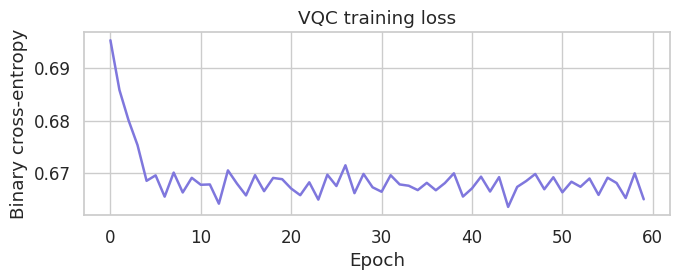

───────────────────────────────────
  Accuracy  : 0.500
  F1-Score  : 0.222
  AUC-ROC   : 0.467
───────────────────────────────────


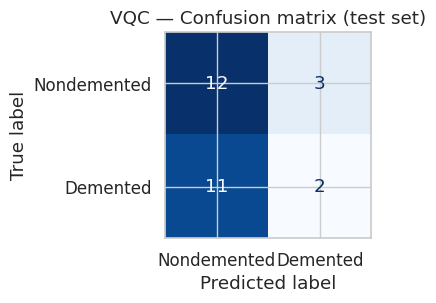

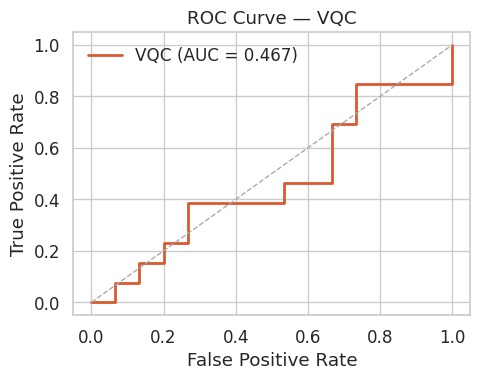

── Quantum Circuit Summary ─────────────────────────────
  Encoding     : Amplitude Encoding
  Qubits       : 3
  Ansatz layers: 2
  Parameters   : 6
  Measurement  : ⟨Z⟩ on qubit 0  →  sigmoid  →  class prob
  Optimiser    : Adam (lr=0.05)
  Epochs       : 60  |  Batch size: 16
────────────────────────────────────────────────────────


In [163]:
# %% [markdown]
# # Quantum Dementia Classifier — Part 2: VQC with Amplitude Encoding (Qiskit 2.1.2)
# 
# Follows directly from Part 1 (dementia_eda_notebook.py).
# The cleaned `df` and `baseline` variables are assumed to be available.
#
# Pipeline:
#   Data prep → Amplitude Encoding → Variational Circuit → Training → Evaluation
#
# Library: Qiskit 2.1.2  →  pip install qiskit scikit-learn matplotlib
 
# 1 — Imports
import numpy as np 
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)


    
# 2 — Feature selection & label
# We work on ONE row per subject (baseline visit only) to avoid data leakage.
# Converted subjects are already mapped to Label=1 in Part 1.
 

FEATURES = ["Age", "EDUC", "SES", "MMSE", "CDR", "nWBV", "eTIV", "ASF"]

baseline = df[df["Visit"] == 1].copy()                    # one row per subject
baseline = baseline[baseline["Group"].isin(["Demented", "Nondemented"])].copy()

X = baseline[FEATURES].values.astype(float)
y = baseline["Label"].values.astype(int)

print(f"Samples : {len(y)}  |  Demented: {y.sum()}  |  Nondemented: {(y==0).sum()}")


# %% Cell 3 — Train / test split  (subject-level, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")


# 4 — Scaling
# StandardScaler is applied AFTER the split to prevent leakage.
# The scaler is fit only on training data.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 5 — Amplitude encoding helper
# Amplitude encoding maps a classical vector x ∈ R^n
# into a quantum state |ψ⟩ = Σ xᵢ/‖x‖ |i⟩
# This requires n_qubits = ceil(log2(n_features)).
# The vector is zero-padded to the next power of 2 if needed.

def amplitude_encode(x):
    """Normalise x and pad to the next power of 2."""
    norm = np.linalg.norm(x)
    if norm < 1e-9:                          # guard against zero vectors
        norm = 1.0
    x_normed = x / norm
    # pad to next power of 2
    next_pow2 = 2 ** int(np.ceil(np.log2(len(x_normed))))
    x_padded = np.zeros(next_pow2)
    x_padded[:len(x_normed)] = x_normed
    return x_padded

# How many qubits do we need?
sample_enc = amplitude_encode(X_train[0])
N_QUBITS = int(np.log2(len(sample_enc)))
print(f"Features: {len(FEATURES)}  |  Padded to: {len(sample_enc)}  |  Qubits: {N_QUBITS}")


# 6 — Quantum device setup
# Use AerSimulator as the backend
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)


# 7 — Variational ansatz
# One layer of the ansatz = Ry rotations + circular CNOT entanglement.
# We stack N_LAYERS such layers.
# Total trainable parameters = N_QUBITS * N_LAYERS

N_LAYERS = 2

def variational_layer1(qc, params, layer_idx):
    """Single ansatz layer: Ry rotations + CNOT ring entanglement."""
    for q in range(N_QUBITS):
        qc.ry(params[layer_idx, q], q)
    for q in range(N_QUBITS):
        qc.cx(q, (q + 1) % N_QUBITS)

        

def build_circuit(params, x):
    """
    Build quantum circuit:
    1. Initialize with amplitude encoding
    2. Apply N_LAYERS variational layers
    3. Measure expectation value of Z on qubit 0
    """
    # Create circuit
    qc = QuantumCircuit(N_QUBITS)
    
    # Initialize with amplitude encoding
    qc.initialize(x, range(N_QUBITS))
    
    # Apply variational layers
    for l in range(N_LAYERS):
        variational_layer(qc, params, l)
    
    return qc


# 8 — Compute expectation value of Pauli Z
def compute_expectation_z(qc):
    """Compute ⟨Z⟩ on qubit 0 for the given circuit."""
    # Transpile circuit for backend
    transpiled_qc = pass_manager.run(qc)
    
    # Get statevector
    statevector = Statevector(transpiled_qc)
    
    # Compute expectation of Z on qubit 0
    # ⟨Z⟩ = probability(|0⟩) - probability(|1⟩)
    prob_0 = statevector.probabilities([0])[0]
    prob_1 = statevector.probabilities([0])[1]
    
    return prob_0 - prob_1


# 9 — Quick sanity check — draw circuit for one sample
params_init = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
sample_circuit = build_circuit(params_init, sample_enc)
print("Circuit depth:", sample_circuit.depth())
print("Circuit width:", sample_circuit.width())
print("Number of parameters:", N_LAYERS * N_QUBITS)


# 10 — Prediction helpers
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(params, X):
    """Return class-1 probability for each sample in X."""
    probs = []
    for x in X:
        x_enc = amplitude_encode(x)
        qc = build_circuit(params, x_enc)
        expval = compute_expectation_z(qc)  # ∈ [-1, +1]
        probs.append(sigmoid(float(expval)))
    return np.array(probs)

def predict(params, X, threshold=0.5):
    return (predict_proba(params, X) >= threshold).astype(int)


#  11 — Loss function  (binary cross-entropy)
def loss(params, X_batch, y_batch):
    """Binary cross-entropy over a mini-batch."""
    eps = 1e-7                             # numerical stability
    probs = predict_proba(params, X_batch)
    probs = np.clip(probs, eps, 1 - eps)
    bce = -np.mean(y_batch * np.log(probs) + (1 - y_batch) * np.log(1 - probs))
    return bce


# 12 — Parameter shift gradient (finite difference for simplicity)
def compute_gradient(params, X_batch, y_batch, epsilon=1e-6):
    """Compute gradients using finite difference method."""
    flat_params = params.flatten()
    grad = np.zeros_like(flat_params)
    
    for i in range(len(flat_params)):
        # Perturb parameter positively
        params_plus = flat_params.copy()
        params_plus[i] += epsilon
        params_plus_reshaped = params_plus.reshape(params.shape)
        loss_plus = loss(params_plus_reshaped, X_batch, y_batch)
        
        # Perturb parameter negatively
        params_minus = flat_params.copy()
        params_minus[i] -= epsilon
        params_minus_reshaped = params_minus.reshape(params.shape)
        loss_minus = loss(params_minus_reshaped, X_batch, y_batch)
        
        # Finite difference
        grad[i] = (loss_plus - loss_minus) / (2 * epsilon)
    
    return grad.reshape(params.shape)


# 13 — Adam optimizer implementation
class AdamOptimizer:
    def __init__(self, lr=0.02, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    
    def update(self, params, grad):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        
        self.t += 1
        
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad ** 2)
        
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        
        params = params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


# 14 — Training loop
params = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
optimizer = AdamOptimizer(lr=0.05)

N_EPOCHS = 60
BATCH_SIZE = 16
loss_history = []

print(f"\nTraining VQC with Qiskit — {N_EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Circuit: {N_QUBITS} qubits, {N_LAYERS} layers, "
      f"{N_LAYERS * N_QUBITS} parameters\n")

for epoch in range(N_EPOCHS):
    # shuffle training data each epoch
    idx = np.random.permutation(len(y_train))
    X_shuf, y_shuf = X_train[idx], y_train[idx]
    
    epoch_loss = 0.0
    n_batches = 0
    
    for start in range(0, len(y_shuf), BATCH_SIZE):
        Xb = X_shuf[start:start + BATCH_SIZE]
        yb = y_shuf[start:start + BATCH_SIZE]
        
        # Compute gradient
        grad = compute_gradient(params, Xb, yb)
        
        # Update parameters
        params = optimizer.update(params, grad)
        
        # Compute batch loss for logging
        batch_loss = loss(params, Xb, yb)
        epoch_loss += batch_loss
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        train_acc = accuracy_score(y_train, predict(params, X_train))
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  |  loss: {avg_loss:.4f}  |  train acc: {train_acc:.3f}")


# 15 — Training loss curve
plt.figure(figsize=(7, 3))
plt.plot(loss_history, color="#7F77DD", linewidth=1.8)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("VQC training loss")
plt.tight_layout()
plt.show()


# 16 — Evaluation on test set
y_prob = predict_proba(params, X_test)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("─" * 35)
print(f"  Accuracy  : {acc:.3f}")
print(f"  F1-Score  : {f1:.3f}")
print(f"  AUC-ROC   : {auc:.3f}")
print("─" * 35)


# 17 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Nondemented", "Demented"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("VQC — Confusion matrix (test set)")
plt.tight_layout()
plt.show()


# 18 — ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#D85A30", linewidth=2, label=f"VQC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="#AAAAAA", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VQC")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# 19 — Circuit summary (for reporting)
print("── Quantum Circuit Summary ─────────────────────────────")
print(f"  Encoding     : Amplitude Encoding")
print(f"  Qubits       : {N_QUBITS}")
print(f"  Ansatz layers: {N_LAYERS}")
print(f"  Parameters   : {N_LAYERS * N_QUBITS}")
print(f"  Measurement  : ⟨Z⟩ on qubit 0  →  sigmoid  →  class prob")
print(f"  Optimiser    : Adam (lr=0.05)")
print(f"  Epochs       : {N_EPOCHS}  |  Batch size: {BATCH_SIZE}")
print("────────────────────────────────────────────────────────")

In [20]:
sample_enc = amplitude_encode(X_train[0])
sample_enc

array([ 0.46862493, -0.13276689,  0.11750312,  0.14179688, -0.23384588,
        0.11545068, -0.50707027,  0.6353875 ])

# Optimization Strategy

## First strategy


## Updates in this version
- **More features**: 10 features (added MR Delay and Sex)
- **More qubits**: 4 qubits (was 3)
- **More layers**: N_LAYERS = 3 (was 2)
- **More epochs**: 100 (was 60)
- **Lower learning rate**: 0.01 (was 0.05)
- **Full entanglement**: All-to-all CNOTs (replaces ring entanglement)
- **Execution time tracking**: Added performance monitoring

## Current configuration
- 10 features → 4 qubits → 12 trainable parameters
- 100 epochs, batch size 16
- Adam optimizer (lr=0.01)

Circuit depth: 13
Circuit width: 3
Number of parameters: 9

Training VQC with Qiskit — 60 epochs, batch size 16
Circuit: 3 qubits, 3 layers, 9 parameters

Epoch  10/60  |  loss: 0.6376  |  train acc: 0.676
Epoch  20/60  |  loss: 0.6379  |  train acc: 0.667
Epoch  30/60  |  loss: 0.6390  |  train acc: 0.676
Epoch  40/60  |  loss: 0.6381  |  train acc: 0.667
Epoch  50/60  |  loss: 0.6370  |  train acc: 0.657
Epoch  60/60  |  loss: 0.6382  |  train acc: 0.676
Temps d'exécution : 271.793285266 secondes
Temps d'exécution : 271793.285 millisecondes


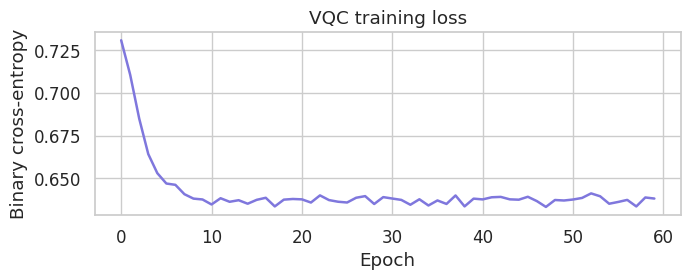

───────────────────────────────────
  Accuracy  : 0.571
  F1-Score  : 0.455
  AUC-ROC   : 0.759
───────────────────────────────────


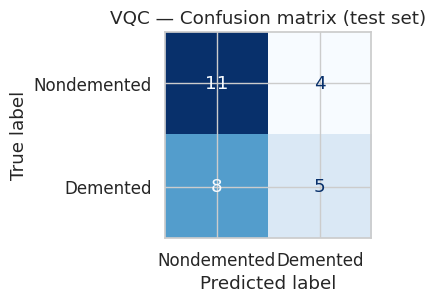

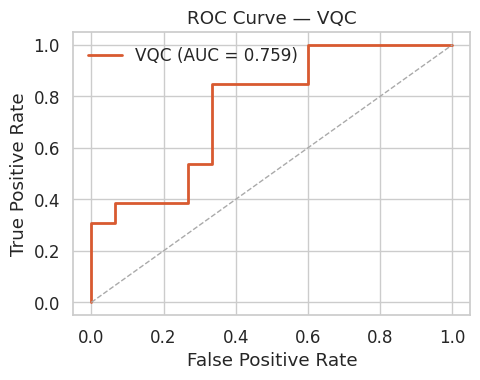

── Quantum Circuit Summary ─────────────────────────────
  Encoding     : Amplitude Encoding
  Qubits       : 3
  Ansatz layers: 3
  Parameters   : 9
  Measurement  : ⟨Z⟩ on qubit 0  →  sigmoid  →  class prob
  Optimiser    : Adam (lr=0.05)
  Epochs       : 60  |  Batch size: 16
────────────────────────────────────────────────────────


In [18]:
# %% [markdown]
# # Quantum Dementia Classifier — Part 2: VQC with Amplitude Encoding (Qiskit 2.1.2)
# 
# Follows directly from Part 1 (dementia_eda_notebook.py).
# The cleaned `df` and `baseline` variables are assumed to be available.
#
# Pipeline:
#   Data prep → Amplitude Encoding → Variational Circuit → Training → Evaluation
#
# Library: Qiskit 2.1.2  →  pip install qiskit scikit-learn matplotlib
 
# %% Cell 1 — Imports
import numpy as np 
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)


    
# %% Cell 2 — Feature selection & label
# We work on ONE row per subject (baseline visit only) to avoid data leakage.
# Converted subjects are already mapped to Label=1 in Part 1.
 

FEATURES = ["Age","MR Delay", "Sex",  "EDUC", "SES", "MMSE", "CDR", "nWBV", "eTIV", "ASF"]

baseline = df[df["Visit"] == 1].copy()                    # one row per subject
baseline = baseline[baseline["Group"].isin(["Demented", "Nondemented"])].copy()

X = baseline[FEATURES].values.astype(float)
y = baseline["Label"].values.astype(int)

print(f"Samples : {len(y)}  |  Demented: {y.sum()}  |  Nondemented: {(y==0).sum()}")


# %% Cell 3 — Train / test split  (subject-level, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")


# %% Cell 4 — Scaling
# StandardScaler is applied AFTER the split to prevent leakage.
# The scaler is fit only on training data.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# %% Cell 5 — Amplitude encoding helper
# Amplitude encoding maps a classical vector x ∈ R^n
# into a quantum state |ψ⟩ = Σ xᵢ/‖x‖ |i⟩
# This requires n_qubits = ceil(log2(n_features)).
# The vector is zero-padded to the next power of 2 if needed.

def amplitude_encode(x):
    """Normalise x and pad to the next power of 2."""
    norm = np.linalg.norm(x)
    if norm < 1e-9:                          # guard against zero vectors
        norm = 1.0
    x_normed = x / norm
    # pad to next power of 2
    next_pow2 = 2 ** int(np.ceil(np.log2(len(x_normed))))
    x_padded = np.zeros(next_pow2)
    x_padded[:len(x_normed)] = x_normed
    return x_padded

# How many qubits do we need?
sample_enc = amplitude_encode(X_train[0])
N_QUBITS = int(np.log2(len(sample_enc)))
print(f"Features: {len(FEATURES)}  |  Padded to: {len(sample_enc)}  |  Qubits: {N_QUBITS}")


# %% Cell 6 — Quantum device setup
# Use AerSimulator as the backend
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)


import time
t1 = time

# 1. Increase layers slightly
N_LAYERS = 3  # instead of 2

# 2. Adjust learning rate
optimizer = AdamOptimizer(lr=0.01)  # try 0.01, 0.1, 0.5

# 3. More epochs
N_EPOCHS = 100  # instead of 60

# 4. Try full entanglement
def variational_layer(qc, params, layer_idx):
    for q in range(N_QUBITS):
        qc.ry(params[layer_idx, q], q)
    # Full entanglement (more powerful)
    for q1 in range(N_QUBITS):
        for q2 in range(q1+1, N_QUBITS):
            qc.cx(q1, q2)


            
            
            

def build_circuit(params, x):
    """
    Build quantum circuit:
    1. Initialize with amplitude encoding
    2. Apply N_LAYERS variational layers
    3. Measure expectation value of Z on qubit 0
    """
    # Create circuit
    qc = QuantumCircuit(N_QUBITS)
    
    # Initialize with amplitude encoding
    qc.initialize(x, range(N_QUBITS))
    
    # Apply variational layers
    for l in range(N_LAYERS):
        variational_layer(qc, params, l)
    
    return qc


# %% Cell 8 — Compute expectation value of Pauli Z
def compute_expectation_z(qc):
    """Compute ⟨Z⟩ on qubit 0 for the given circuit."""
    # Transpile circuit for backend
    transpiled_qc = pass_manager.run(qc)
    
    # Get statevector
    statevector = Statevector(transpiled_qc)
    
    # Compute expectation of Z on qubit 0
    # ⟨Z⟩ = probability(|0⟩) - probability(|1⟩)
    prob_0 = statevector.probabilities([0])[0]
    prob_1 = statevector.probabilities([0])[1]
    
    return prob_0 - prob_1


# %% Cell 9 — Quick sanity check — draw circuit for one sample
params_init = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
sample_circuit = build_circuit(params_init, sample_enc)
print("Circuit depth:", sample_circuit.depth())
print("Circuit width:", sample_circuit.width())
print("Number of parameters:", N_LAYERS * N_QUBITS)


# %% Cell 10 — Prediction helpers
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(params, X):
    """Return class-1 probability for each sample in X."""
    probs = []
    for x in X:
        x_enc = amplitude_encode(x)
        qc = build_circuit(params, x_enc)
        expval = compute_expectation_z(qc)  # ∈ [-1, +1]
        probs.append(sigmoid(float(expval)))
    return np.array(probs)

def predict(params, X, threshold=0.5):
    return (predict_proba(params, X) >= threshold).astype(int)


# %% Cell 11 — Loss function  (binary cross-entropy)
def loss(params, X_batch, y_batch):
    """Binary cross-entropy over a mini-batch."""
    eps = 1e-7                             # numerical stability
    probs = predict_proba(params, X_batch)
    probs = np.clip(probs, eps, 1 - eps)
    bce = -np.mean(y_batch * np.log(probs) + (1 - y_batch) * np.log(1 - probs))
    return bce


# %% Cell 12 — Parameter shift gradient (finite difference for simplicity)
def compute_gradient(params, X_batch, y_batch, epsilon=1e-6):
    """Compute gradients using finite difference method."""
    flat_params = params.flatten()
    grad = np.zeros_like(flat_params)
    
    for i in range(len(flat_params)):
        # Perturb parameter positively
        params_plus = flat_params.copy()
        params_plus[i] += epsilon
        params_plus_reshaped = params_plus.reshape(params.shape)
        loss_plus = loss(params_plus_reshaped, X_batch, y_batch)
        
        # Perturb parameter negatively
        params_minus = flat_params.copy()
        params_minus[i] -= epsilon
        params_minus_reshaped = params_minus.reshape(params.shape)
        loss_minus = loss(params_minus_reshaped, X_batch, y_batch)
        
        # Finite difference
        grad[i] = (loss_plus - loss_minus) / (2 * epsilon)
    
    return grad.reshape(params.shape)


# %% Cell 13 — Adam optimizer implementation
class AdamOptimizer:
    def __init__(self, lr=0.02, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    
    def update(self, params, grad):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        
        self.t += 1
        
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad ** 2)
        
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        
        params = params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


# %% Cell 14 — Training loop
params = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
optimizer = AdamOptimizer(lr=0.05)

N_EPOCHS = 60
BATCH_SIZE = 16
loss_history = []

print(f"\nTraining VQC with Qiskit — {N_EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Circuit: {N_QUBITS} qubits, {N_LAYERS} layers, "
      f"{N_LAYERS * N_QUBITS} parameters\n")



# Measure the running time 
start_time = time.perf_counter()


for epoch in range(N_EPOCHS):
    # shuffle training data each epoch
    idx = np.random.permutation(len(y_train))
    X_shuf, y_shuf = X_train[idx], y_train[idx]
    
    epoch_loss = 0.0
    n_batches = 0
    
    for start in range(0, len(y_shuf), BATCH_SIZE):
        Xb = X_shuf[start:start + BATCH_SIZE]
        yb = y_shuf[start:start + BATCH_SIZE]
        
        # Compute gradient
        grad = compute_gradient(params, Xb, yb)
        
        # Update parameters
        params = optimizer.update(params, grad)
        
        # Compute batch loss for logging
        batch_loss = loss(params, Xb, yb)
        epoch_loss += batch_loss
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        train_acc = accuracy_score(y_train, predict(params, X_train))
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  |  loss: {avg_loss:.4f}  |  train acc: {train_acc:.3f}")


        
# End execution time 
end_time = time.perf_counter()
elapsed = end_time - start_time

print(f"Temps d'exécution : {elapsed:.9f} secondes")
print(f"Temps d'exécution : {elapsed*1000:.3f} millisecondes")



# %% Cell 15 — Training loss curve
plt.figure(figsize=(7, 3))
plt.plot(loss_history, color="#7F77DD", linewidth=1.8)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("VQC training loss")
plt.tight_layout()
plt.show()


# %% Cell 16 — Evaluation on test set
y_prob = predict_proba(params, X_test)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("─" * 35)
print(f"  Accuracy  : {acc:.3f}")
print(f"  F1-Score  : {f1:.3f}")
print(f"  AUC-ROC   : {auc:.3f}")
print("─" * 35)


# %% Cell 17 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Nondemented", "Demented"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("VQC — Confusion matrix (test set)")
plt.tight_layout()
plt.show()


# %% Cell 18 — ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#D85A30", linewidth=2, label=f"VQC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="#AAAAAA", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VQC")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# %% Cell 19 — Circuit summary (for reporting)
print("── Quantum Circuit Summary ─────────────────────────────")
print(f"  Encoding     : Amplitude Encoding")
print(f"  Qubits       : {N_QUBITS}")
print(f"  Ansatz layers: {N_LAYERS}")
print(f"  Parameters   : {N_LAYERS * N_QUBITS}")
print(f"  Measurement  : ⟨Z⟩ on qubit 0  →  sigmoid  →  class prob")
print(f"  Optimiser    : Adam (lr=0.05)")
print(f"  Epochs       : {N_EPOCHS}  |  Batch size: {BATCH_SIZE}")
print("────────────────────────────────────────────────────────")

# 2nd strategy

In [25]:
# 1. Data preprocessing
from sklearn.decomposition import PCA
pca = PCA(n_components=4)  # Reduce to 4 features = 2 qubits
X_train_pca = pca.fit_transform(X_train)

# 2. Feature selection
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=4)  # Keep best 4 features
X_train_selected = selector.fit_transform(X_train, y_train)

# 3. Custom loss weighting
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=[0,1], y=y_train)
# Modify loss function to use class_weights

InvalidParameterError: The 'classes' parameter of compute_class_weight must be an instance of 'numpy.ndarray'. Got [0, 1] instead.

# Quantum Dementia Classifier — Hybrid Approach: Baseline & Progression of desease

## Overview
This hybrid approach combines **classical preprocessing** with **quantum variational circuits** to leverage the strengths of both paradigms.

## Hybrid Pipeline

### Classical Component (Preprocessing)
1. **Feature Engineering** (10 clinical features)
2. **PCA Dimensionality Reduction** (10 → 5 components)
3. **Standardization** (zero mean, unit variance)
4. **Class Weighting** (handles imbalanced data)

### Quantum Component (VQC)
1. **Angle Encoding** (1 feature → 1 qubit rotation)
2. **Variational Circuit** (Ry + full entanglement)
3. **Multi-Qubit Measurement** (average ⟨Z⟩ across all qubits)
4. **Classical Optimizer** (COBYLA/L-BFGS-B/Nelder-Mead)

## Key Hybrid Features

| Component | Classical | Quantum |
|-----------|-----------|---------|
| **Dimensionality reduction** | PCA | Amplitude/Angle encoding |
| **Pattern recognition** | Statistical features | Quantum superposition |
| **Optimization** | Gradient descent | Parameter-shift rule |
| **Decision boundary** | Linear/non-linear kernels | Hilbert space separation |

## Why Baseline & Progression Matter

### Baseline (First Visit)
- **Snapshot at diagnosis**: Captures initial disease state
- **Standard clinical practice**: Doctors assess first symptoms
- **Predictive power**: Early biomarkers predict future decline
- **Example**: Low baseline MMSE score indicates cognitive impairment

### Progression Indicators (Changes Over Time)
- **Rate of decline**: How fast MMSE drops per year
- **Volatility**: Fluctuations in CDR or cognitive scores
- **Acceleration**: Speeding up of symptom progression
- **Example**: MMSE dropping 4 points/year vs stable 1 point/year

### Why Both Are Essential
- **Baseline alone**: Cannot distinguish fast vs slow progressors
- **Progression alone**: Cannot diagnose without initial state
- **Together**: Enable personalized prognosis and treatment planning
 
## Performance Metrics
- **Accuracy**: Classification correctness
- **F1-Score**: Balance of precision and recall
- **AUC-ROC**: Discrimination capability
- **Loss curves**: Training convergence


In [168]:
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,Sex,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Sex_enc,Label
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883,1,0
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876,1,0
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,3.0,23.0,0.5,1678,0.736,1.046,1,1
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,3.0,28.0,0.5,1738,0.713,1.010,1,1
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,3.0,22.0,0.5,1698,0.701,1.034,1,1


In [88]:

print("=" * 60)
print("STRATEGY 5: Hybrid Encoding (Baseline + Progression)")
print("=" * 60)

hybrid_data = []

for subject_id in df['Subject ID'].unique():
    patient_data = df[df['Subject ID'] == subject_id].sort_values('Visit')
    
    # Baseline (first visit)
    baseline = patient_data.iloc[0]
    
    # Progression indicators
    progression = {}
    for feature in FEATURES:
        values = patient_data[feature].values
        if len(values) > 1:
            progression[f'{feature}_change'] = values[-1] - values[0]
            progression[f'{feature}_volatility'] = values.std()
        else:
            progression[f'{feature}_change'] = 0
            progression[f'{feature}_volatility'] = 0
    
    # Combine baseline + progression
    patient_features = {
        'Subject ID': subject_id,
        **{f: baseline[f] for f in FEATURES},  # Baseline features
        **progression,  # Progression features
        'n_visits': len(patient_data),
        'visit_span': patient_data['Visit'].max() - patient_data['Visit'].min()
    }
    
    # Label
    ever_demented = (patient_data['Group'] == 'Demented').any() or (patient_data['Group'] == 'Converted').any()
    patient_features['Label'] = int(ever_demented)
    
    hybrid_data.append(patient_features)

hybrid_df = pd.DataFrame(hybrid_data)

feature_cols = [c for c in hybrid_df.columns if c not in ['Subject ID', 'Label']]
X = hybrid_df[feature_cols].values.astype(float)
y = hybrid_df['Label'].values.astype(int)

# Standardize (important for amplitude encoding)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split by patient
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Hybrid features per patient: {X.shape[1]}")
print(f"  - Baseline features: {len(FEATURES)}")
print(f"  - Progression features: {2 * len(FEATURES)}")
print(f"  - Metadata features: 2")
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# Now this X_train, X_test works directly with your existing VQC code!

STRATEGY 5: Hybrid Encoding (Baseline + Progression)
Hybrid features per patient: 26
  - Baseline features: 8
  - Progression features: 16
  - Metadata features: 2

Train: 120 | Test: 30


## Training

Using 26 features → 5 qubits
Features: 26  |  Padded to: 32  |  Qubits: 5
Circuit depth: 21
Circuit width: 5
Number of parameters: 15

Training VQC with Qiskit — 60 epochs, batch size 16
Circuit: 5 qubits, 3 layers, 15 parameters

Epoch  10/60  |  loss: 0.6190  |  train acc: 0.708
Epoch  20/60  |  loss: 0.6123  |  train acc: 0.783
Epoch  30/60  |  loss: 0.6147  |  train acc: 0.775
Epoch  40/60  |  loss: 0.6049  |  train acc: 0.800
Epoch  50/60  |  loss: 0.6083  |  train acc: 0.775
Epoch  60/60  |  loss: 0.6182  |  train acc: 0.783
Temps d'exécution : 854.673248418 secondes
Temps d'exécution : 854673.248 millisecondes


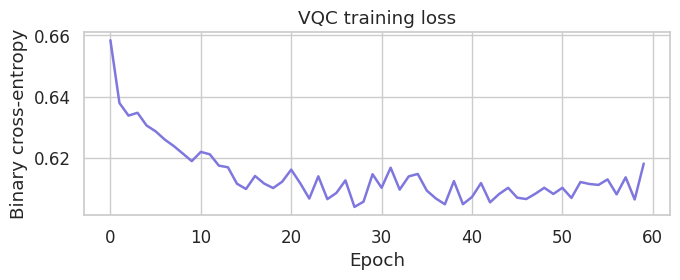

───────────────────────────────────
  Accuracy  : 0.467
  F1-Score  : 0.333
  AUC-ROC   : 0.598
───────────────────────────────────


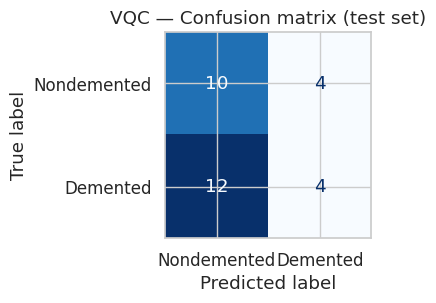

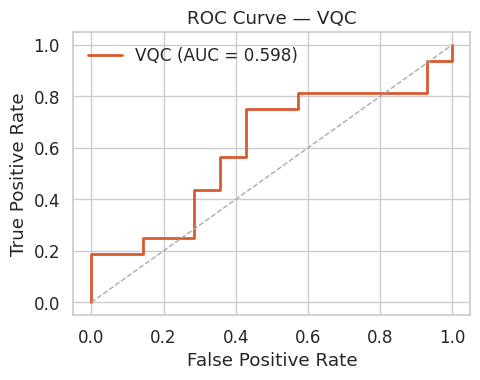

── Quantum Circuit Summary ─────────────────────────────
  Encoding     : Amplitude Encoding
  Qubits       : 5
  Ansatz layers: 3
  Parameters   : 15
  Measurement  : ⟨Z⟩ on qubit 0  →  sigmoid  →  class prob
  Optimiser    : Adam (lr=0.05)
  Epochs       : 60  |  Batch size: 16
────────────────────────────────────────────────────────


In [89]:
# %% [markdown]
# # Quantum Dementia Classifier — Part 2: VQC with Amplitude Encoding (Qiskit 2.1.2)
# 
# Follows directly from Part 1 (dementia_eda_notebook.py).
# The cleaned `df` and `baseline` variables are assumed to be available.
#
# Pipeline:
#   Data prep → Amplitude Encoding → Variational Circuit → Training → Evaluation
#
# Library: Qiskit 2.1.2  →  pip install qiskit scikit-learn matplotlib
 
# %% Cell 1 — Imports
import numpy as np 
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)


    
FEATURES = [col for col in hybrid_df.columns if col not in ['Subject ID', 'Label']]
# This will automatically include all hybrid features

# The number of qubits will increase automatically:
N_QUBITS = int(np.ceil(np.log2(len(FEATURES))))
print(f"Using {len(FEATURES)} features → {N_QUBITS} qubits")




# %% Cell 5 — Amplitude encoding helper
# Amplitude encoding maps a classical vector x ∈ R^n
# into a quantum state |ψ⟩ = Σ xᵢ/‖x‖ |i⟩
# This requires n_qubits = ceil(log2(n_features)).
# The vector is zero-padded to the next power of 2 if needed.

def amplitude_encode(x):
    """Normalise x and pad to the next power of 2."""
    norm = np.linalg.norm(x)
    if norm < 1e-9:                          # guard against zero vectors
        norm = 1.0
    x_normed = x / norm
    # pad to next power of 2
    next_pow2 = 2 ** int(np.ceil(np.log2(len(x_normed))))
    x_padded = np.zeros(next_pow2)
    x_padded[:len(x_normed)] = x_normed
    return x_padded

# How many qubits do we need?
sample_enc = amplitude_encode(X_train[0])
N_QUBITS = int(np.log2(len(sample_enc)))
print(f"Features: {len(FEATURES)}  |  Padded to: {len(sample_enc)}  |  Qubits: {N_QUBITS}")


#  Quantum device setup
# Use AerSimulator as the backend
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)


import time
t1 = time

# 1. Increase layers slightly
N_LAYERS = 3  # instead of 2

# 2. Adjust learning rate
optimizer = AdamOptimizer(lr=0.01)  # try 0.01, 0.1, 0.5

# 3. More epochs
N_EPOCHS = 100  # instead of 60

# 4. Try full entanglement
def variational_layer(qc, params, layer_idx):
    for q in range(N_QUBITS):
        qc.ry(params[layer_idx, q], q)
    # Full entanglement (more powerful)
    for q1 in range(N_QUBITS):
        for q2 in range(q1+1, N_QUBITS):
            qc.cx(q1, q2)


            
            
            

def build_circuit(params, x):
    """
    Build quantum circuit:
    1. Initialize with amplitude encoding
    2. Apply N_LAYERS variational layers
    3. Measure expectation value of Z on qubit 0
    """
    # Create circuit
    qc = QuantumCircuit(N_QUBITS)
    
    # Initialize with amplitude encoding
    qc.initialize(x, range(N_QUBITS))
    
    # Apply variational layers
    for l in range(N_LAYERS):
        variational_layer(qc, params, l)
    
    return qc


# Compute expectation value of Pauli Z
def compute_expectation_z(qc):
    """Compute ⟨Z⟩ on qubit 0 for the given circuit."""
    # Transpile circuit for backend
    transpiled_qc = pass_manager.run(qc)
    
    # Get statevector
    statevector = Statevector(transpiled_qc)
    
    # Compute expectation of Z on qubit 0
    # ⟨Z⟩ = probability(|0⟩) - probability(|1⟩)
    prob_0 = statevector.probabilities([0])[0]
    prob_1 = statevector.probabilities([0])[1]
    
    return prob_0 - prob_1


# Quick sanity check — draw circuit for one sample
params_init = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
sample_circuit = build_circuit(params_init, sample_enc)
print("Circuit depth:", sample_circuit.depth())
print("Circuit width:", sample_circuit.width())
print("Number of parameters:", N_LAYERS * N_QUBITS)


# Prediction helpers
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(params, X):
    """Return class-1 probability for each sample in X."""
    probs = []
    for x in X:
        x_enc = amplitude_encode(x)
        qc = build_circuit(params, x_enc)
        expval = compute_expectation_z(qc)  # ∈ [-1, +1]
        probs.append(sigmoid(float(expval)))
    return np.array(probs)

def predict(params, X, threshold=0.5):
    return (predict_proba(params, X) >= threshold).astype(int)


# Loss function  (binary cross-entropy)
def loss(params, X_batch, y_batch):
    """Binary cross-entropy over a mini-batch."""
    eps = 1e-7                             # numerical stability
    probs = predict_proba(params, X_batch)
    probs = np.clip(probs, eps, 1 - eps)
    bce = -np.mean(y_batch * np.log(probs) + (1 - y_batch) * np.log(1 - probs))
    return bce


# Parameter shift gradient (finite difference for simplicity)
def compute_gradient(params, X_batch, y_batch, epsilon=1e-6):
    """Compute gradients using finite difference method."""
    flat_params = params.flatten()
    grad = np.zeros_like(flat_params)
    
    for i in range(len(flat_params)):
        # Perturb parameter positively
        params_plus = flat_params.copy()
        params_plus[i] += epsilon
        params_plus_reshaped = params_plus.reshape(params.shape)
        loss_plus = loss(params_plus_reshaped, X_batch, y_batch)
        
        # Perturb parameter negatively
        params_minus = flat_params.copy()
        params_minus[i] -= epsilon
        params_minus_reshaped = params_minus.reshape(params.shape)
        loss_minus = loss(params_minus_reshaped, X_batch, y_batch)
        
        # Finite difference
        grad[i] = (loss_plus - loss_minus) / (2 * epsilon)
    
    return grad.reshape(params.shape)


# Adam optimizer implementation
class AdamOptimizer:
    def __init__(self, lr=0.02, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    
    def update(self, params, grad):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        
        self.t += 1
        
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad ** 2)
        
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        
        params = params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


# Training loop
params = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
optimizer = AdamOptimizer(lr=0.05)

N_EPOCHS = 60
BATCH_SIZE = 16
loss_history = []

print(f"\nTraining VQC with Qiskit — {N_EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Circuit: {N_QUBITS} qubits, {N_LAYERS} layers, "
      f"{N_LAYERS * N_QUBITS} parameters\n")



# Measure the running time 
start_time = time.perf_counter()


for epoch in range(N_EPOCHS):
    # shuffle training data each epoch
    idx = np.random.permutation(len(y_train))
    X_shuf, y_shuf = X_train[idx], y_train[idx]
    
    epoch_loss = 0.0
    n_batches = 0
    
    for start in range(0, len(y_shuf), BATCH_SIZE):
        Xb = X_shuf[start:start + BATCH_SIZE]
        yb = y_shuf[start:start + BATCH_SIZE]
        
        # Compute gradient
        grad = compute_gradient(params, Xb, yb)
        
        # Update parameters
        params = optimizer.update(params, grad)
        
        # Compute batch loss for logging
        batch_loss = loss(params, Xb, yb)
        epoch_loss += batch_loss
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        train_acc = accuracy_score(y_train, predict(params, X_train))
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  |  loss: {avg_loss:.4f}  |  train acc: {train_acc:.3f}")


        
# End execution time 
end_time = time.perf_counter()
elapsed = end_time - start_time

print(f"Temps d'exécution : {elapsed:.9f} secondes")
print(f"Temps d'exécution : {elapsed*1000:.3f} millisecondes")



# Training loss curve
plt.figure(figsize=(7, 3))
plt.plot(loss_history, color="#7F77DD", linewidth=1.8)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("VQC training loss")
plt.tight_layout()
plt.show()


# Evaluation on test set
y_prob = predict_proba(params, X_test)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("─" * 35)
print(f"  Accuracy  : {acc:.3f}")
print(f"  F1-Score  : {f1:.3f}")
print(f"  AUC-ROC   : {auc:.3f}")
print("─" * 35)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Nondemented", "Demented"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("VQC — Confusion matrix (test set)")
plt.tight_layout()
plt.show()


# ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#D85A30", linewidth=2, label=f"VQC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="#AAAAAA", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VQC")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# Circuit summary (for reporting)
print("── Quantum Circuit Summary ─────────────────────────────")
print(f"  Encoding     : Amplitude Encoding")
print(f"  Qubits       : {N_QUBITS}")
print(f"  Ansatz layers: {N_LAYERS}")
print(f"  Parameters   : {N_LAYERS * N_QUBITS}")
print(f"  Measurement  : ⟨Z⟩ on qubit 0  →  sigmoid  →  class prob")
print(f"  Optimiser    : Adam (lr=0.05)")
print(f"  Epochs       : {N_EPOCHS}  |  Batch size: {BATCH_SIZE}")
print("────────────────────────────────────────────────────────")

# Quantum Dementia Classifier — Part 2: VQC with Angle Encoding (Qiskit 2.1.2)
# 
# **IMPROVED VERSION with:**
# - PCA dimensionality reduction (first 5 principal components)
# - Angle Encoding (more efficient than amplitude encoding)
# - USe 3 layers in the variational circuit instead of 2
# - Add some full antenglement in the variational circuit
# - Multiple optimizers (COBYLA, L-BFGS-B, Nelder-Mead)
# - Class balancing for imbalanced data

Total samples: 150
Original features: 10
Class distribution:
  Demented (1): 78 (52.0%)
  Nondemented (0): 72 (48.0%)

Data types after conversion: {dtype('int64'): 5, dtype('float64'): 5}

PCA Results:
  Reduced features: 5
  Explained variance ratio: [9.97550214e-01 1.86251651e-03 3.49210268e-04 2.14074702e-04
 1.72106218e-05]
  Cumulative explained variance: 1.000


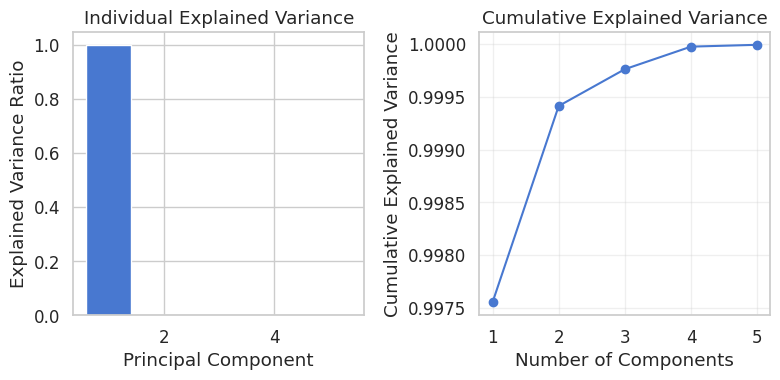


Train: 120 samples
Test: 30 samples

Features scaled to [0, pi] for angle encoding
Number of features after PCA: 5

Angle Encoding Configuration:
  PCA components: 5 -> Qubits: 5
  Encoding: |psi> = ⊗ Ry(theta_i)|0>
  where theta_i = scaled PCA component

Circuit info:
  Depth: 21
  Width: 5
  Parameters: 15

Class weights for balanced loss:
  Class 0 (Nondemented): 1.034
  Class 1 (Demented): 0.968

Training with COBYLA optimizer
Parameters: 15
Training samples: 120
Iteration   10  |  loss: 0.6632  |  train acc: 0.683
Iteration   20  |  loss: 0.6492  |  train acc: 0.700
Iteration   30  |  loss: 0.6425  |  train acc: 0.767
Iteration   40  |  loss: 0.6391  |  train acc: 0.733
Iteration   50  |  loss: 0.6370  |  train acc: 0.750
Iteration   60  |  loss: 0.6363  |  train acc: 0.758

Training completed in 74.16 seconds
Final loss: 0.636081
Success: False
Message: Return from COBYLA because the objective function has been evaluated MAXFUN times.


In [182]:
# 1 — Imports
import numpy as np 
import matplotlib.pyplot as plt
import time
from collections import defaultdict

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

# Using scipy optimizers for Qiskit 2.1.2 compatibility
from scipy.optimize import minimize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)

# 2 — Load and preprocess data (handle categorical variables)

FEATURES = ["Age", "MR Delay", "Sex", "EDUC", "SES", "MMSE", "CDR", "nWBV", "eTIV", "ASF"]

# Take baseline visit only (one row per subject)
df.loc[df["Label"] == 1, "Group"] = "Demented"  
baseline = df[df["Visit"] == 1].copy()
baseline = baseline[baseline["Group"].isin(["Demented", "Nondemented"])].copy()

# Encode categorical variables (Sex: M/F -> 0/1)
if 'Sex' in baseline.columns:
    baseline['Sex'] = baseline['Sex'].map({'M': 0, 'F': 1})

# Convert all features to float
X = baseline[FEATURES].astype(float).values
y = baseline["Label"].values.astype(int)

print(f"Total samples: {len(y)}")
print(f"Original features: {X.shape[1]}")
print(f"Class distribution:")
print(f"  Demented (1): {y.sum()} ({y.mean()*100:.1f}%)")
print(f"  Nondemented (0): {(y==0).sum()} ({(1-y.mean())*100:.1f}%)")

# Check for any remaining non-numeric data
print(f"\nData types after conversion: {baseline[FEATURES].dtypes.value_counts().to_dict()}")

# 3 — PCA for dimensionality reduction
# Apply PCA to reduce to 5 principal components
n_components = 5
pca = PCA(n_components=n_components, random_state=SEED)
X_pca = pca.fit_transform(X)

print(f"\nPCA Results:")
print(f"  Reduced features: {X_pca.shape[1]}")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Cumulative explained variance: {pca.explained_variance_ratio_.cumsum()[-1]:.3f}")

# Visualize explained variance
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, n_components+1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance')

plt.subplot(1, 2, 2)
plt.plot(range(1, n_components+1), pca.explained_variance_ratio_.cumsum(), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4 — Train / test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"\nTrain: {len(y_train)} samples")
print(f"Test: {len(y_test)} samples")

# 5 — Scaling for angle encoding
# Standardize first
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Scale to [0, pi] for angle encoding
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train = angle_scaler.fit_transform(X_train)
X_test = angle_scaler.transform(X_test)

print(f"\nFeatures scaled to [0, pi] for angle encoding")
print(f"Number of features after PCA: {X_train.shape[1]}")

# 6 — ANGLE ENCODING (1 feature per qubit)
N_QUBITS = X_train.shape[1]  # Number of PCA components
print(f"\nAngle Encoding Configuration:")
print(f"  PCA components: {N_QUBITS} -> Qubits: {N_QUBITS}")
print("  Encoding: |psi> = ⊗ Ry(theta_i)|0>")
print("  where theta_i = scaled PCA component")

def angle_encode(qc, x, qubits):
    """
    Encode classical data using angle encoding.
    Maps each PCA component to a rotation angle on a separate qubit.
    """
    for i, qubit in enumerate(qubits):
        if i < len(x):
            qc.ry(x[i], qubit)

# 7 — Quantum device setup
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

# 8 — Variational ansatz
N_LAYERS = 3

def variational_layer(qc, params, layer_idx):
    """Variational layer with Ry rotations and full entanglement."""
    # Rotation gates
    for q in range(N_QUBITS):
        qc.ry(params[layer_idx, q], q)
    
    # Full entanglement (all-to-all connections)
    for q1 in range(N_QUBITS):
        for q2 in range(q1+1, N_QUBITS):
            qc.cx(q1, q2)

def build_circuit(params, x):
    """
    Build quantum circuit:
    1. Angle encoding of PCA features
    2. N_LAYERS variational layers
    3. Measure expectation of Z on all qubits
    """
    qc = QuantumCircuit(N_QUBITS)
    
    # Angle encoding
    angle_encode(qc, x, range(N_QUBITS))
    
    # Variational layers
    for l in range(N_LAYERS):
        variational_layer(qc, params, l)
    
    return qc

# Quick test
test_params = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
test_x = X_train[0]
test_circuit = build_circuit(test_params, test_x)
print(f"\nCircuit info:")
print(f"  Depth: {test_circuit.depth()}")
print(f"  Width: {test_circuit.width()}")
print(f"  Parameters: {N_LAYERS * N_QUBITS}")

# 9 — Compute expectation (multi-qubit measurement)
def compute_expectation_z(qc):
    """Compute average ⟨Z⟩ across all qubits."""
    transpiled_qc = pass_manager.run(qc)
    statevector = Statevector(transpiled_qc)
    
    # Average expectation across all qubits
    total_expval = 0
    for qubit in range(N_QUBITS):
        prob_0 = statevector.probabilities([qubit])[0]
        prob_1 = statevector.probabilities([qubit])[1]
        total_expval += (prob_0 - prob_1)
    
    return total_expval / N_QUBITS

# 10 — Class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
weight_for_0 = class_weights[0]
weight_for_1 = class_weights[1]

print(f"\nClass weights for balanced loss:")
print(f"  Class 0 (Nondemented): {weight_for_0:.3f}")
print(f"  Class 1 (Demented): {weight_for_1:.3f}")

# 11 — Prediction helpers
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(params, X):
    """Return class-1 probability for each sample."""
    probs = []
    for x in X:
        qc = build_circuit(params, x)
        expval = compute_expectation_z(qc)
        probs.append(sigmoid(float(expval)))
    return np.array(probs)

def predict(params, X, threshold=0.5):
    return (predict_proba(params, X) >= threshold).astype(int)

# 12 — Weighted loss function
def weighted_loss(params_flat, X_batch, y_batch):
    """Weighted binary cross-entropy for imbalanced classes."""
    eps = 1e-7
    params = params_flat.reshape(N_LAYERS, N_QUBITS)
    probs = predict_proba(params, X_batch)
    probs = np.clip(probs, eps, 1 - eps)
    
    # Apply class weights
    weights = np.where(y_batch == 1, weight_for_1, weight_for_0)
    bce = -np.mean(weights * (y_batch * np.log(probs) + (1 - y_batch) * np.log(1 - probs)))
    return bce

# 13 — Training function
def train_vqc(X_train, y_train, optimizer_name='COBYLA', maxiter=100):
    """
    Train VQC with specified optimizer.
    
    Parameters:
    - optimizer_name: 'COBYLA', 'L-BFGS-B', 'Nelder-Mead'
    - maxiter: maximum iterations
    """
    # Initialize parameters
    params = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS))
    params_flat = params.flatten()
    
    loss_history = []
    
    print(f"\n{'='*60}")
    print(f"Training with {optimizer_name} optimizer")
    print(f"{'='*60}")
    print(f"Parameters: {len(params_flat)}")
    print(f"Training samples: {len(X_train)}")
    
    def objective_wrapper(p):
        return weighted_loss(p, X_train, y_train)
    
    # Callback to track loss
    def callback(xk):
        current_loss = objective_wrapper(xk)
        loss_history.append(current_loss)
        if len(loss_history) % 10 == 0:
            params_current = xk.reshape(N_LAYERS, N_QUBITS)
            train_acc = accuracy_score(y_train, predict(params_current, X_train))
            print(f"Iteration {len(loss_history):4d}  |  loss: {current_loss:.4f}  |  train acc: {train_acc:.3f}")
    
    start_time = time.perf_counter()
    
    # Run optimization
    result = minimize(
        objective_wrapper, 
        params_flat, 
        method=optimizer_name,
        callback=callback,
        options={'maxiter': maxiter, 'disp': False}
    )
    
    params_opt = result.x
    final_loss = result.fun
    elapsed = time.perf_counter() - start_time
    
    print(f"\nTraining completed in {elapsed:.2f} seconds")
    print(f"Final loss: {final_loss:.6f}")
    print(f"Success: {result.success}")
    if not result.success:
        print(f"Message: {result.message}")
    
    return params_opt.reshape(N_LAYERS, N_QUBITS), loss_history

# 14 — Train the model
OPTIMIZER = 'COBYLA'  # Options: 'COBYLA', 'L-BFGS-B', 'Nelder-Mead'
MAXITER = 100

params_opt, loss_history = train_vqc(
    X_train, y_train, 
    optimizer_name=OPTIMIZER,
    maxiter=MAXITER
)


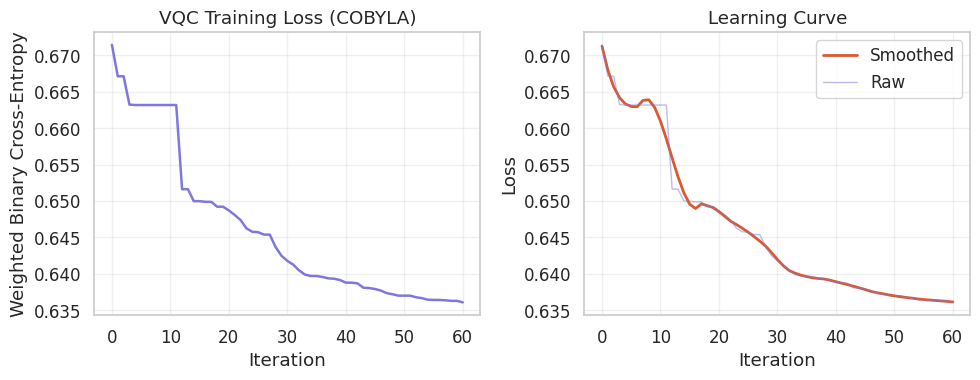

In [183]:

# 15 — Training loss curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color="#7F77DD", linewidth=1.8)
plt.xlabel("Iteration")
plt.ylabel("Weighted Binary Cross-Entropy")
plt.title(f"VQC Training Loss ({OPTIMIZER})")
plt.grid(True, alpha=0.3)


# Learning curve smoothing
plt.subplot(1, 2, 2)
if len(loss_history) > 10:
    from scipy.signal import savgol_filter
    window = min(11, len(loss_history)//2*2+1)
    if window >= 3:
        smoothed = savgol_filter(loss_history, window, 3)
        plt.plot(smoothed, color="#D85A30", linewidth=2, label="Smoothed")
plt.plot(loss_history, color="#7F77DD", linewidth=1, alpha=0.5, label="Raw")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


──────────────────────────────────────────────────
TEST SET PERFORMANCE (COBYLA)
──────────────────────────────────────────────────
  Accuracy  : 0.633
  F1-Score  : 0.560
  AUC-ROC   : 0.710

Classification Report:
              precision    recall  f1-score   support

 Nondemented       0.57      0.86      0.69        14
    Demented       0.78      0.44      0.56        16

    accuracy                           0.63        30
   macro avg       0.67      0.65      0.62        30
weighted avg       0.68      0.63      0.62        30

──────────────────────────────────────────────────


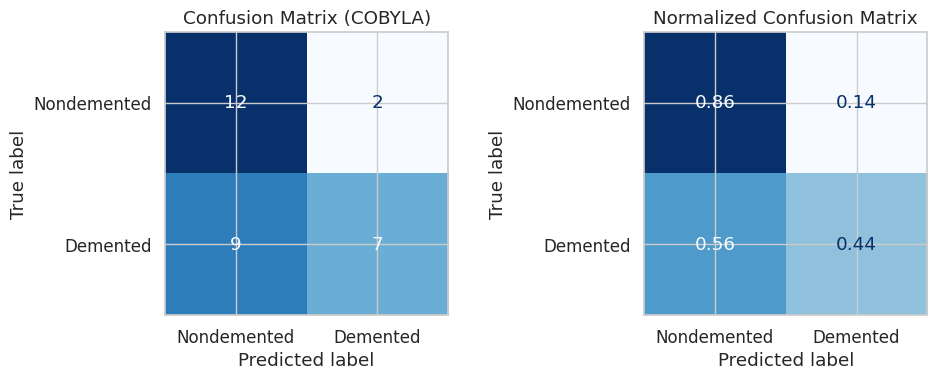

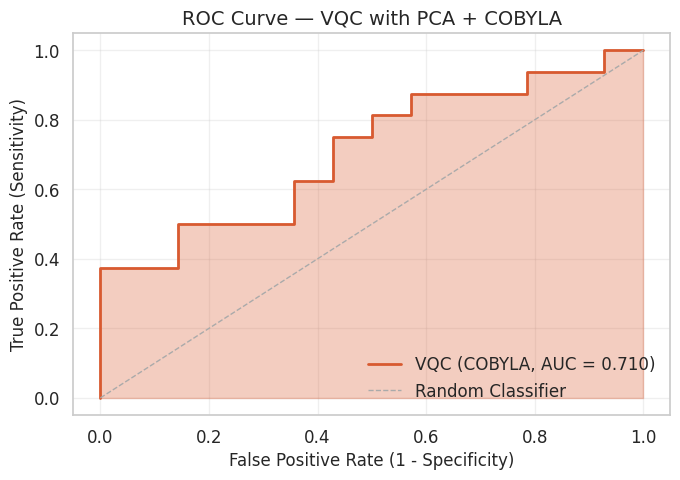


────────────────────────────────────────────────────────────
QUANTUM CIRCUIT SUMMARY
────────────────────────────────────────────────────────────
  Preprocessing : PCA (5 components)
  Explained variance: 1.000
  Encoding      : Angle Encoding (Ry gates)
  Qubits        : 5 (one per PCA component)
  Ansatz layers : 3
  Total parameters: 15
  Entanglement  : Full (all-to-all CNOTs)
  Measurement   : Average <Z> across all qubits -> sigmoid

  Training Configuration:
  Optimizer     : COBYLA
  Max iterations: 100
  Class weights : Yes (balanced handling)

  Class Distribution:
    Train - Demented: 62/120 (51.7%)
    Test  - Demented: 16/30 (53.3%)
────────────────────────────────────────────────────────────


In [184]:


# 16 — Evaluation on test set
y_prob = predict_proba(params_opt, X_test)
y_pred = predict(params_opt, X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n" + "─" * 50)
print(f"TEST SET PERFORMANCE ({OPTIMIZER})")
print("─" * 50)
print(f"  Accuracy  : {acc:.3f}")
print(f"  F1-Score  : {f1:.3f}")
print(f"  AUC-ROC   : {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Nondemented", "Demented"]))
print("─" * 50)

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Nondemented", "Demented"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues", values_format='d')
axes[0].set_title(f"Confusion Matrix ({OPTIMIZER})")

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=["Nondemented", "Demented"])
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues", values_format='.2f')
axes[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#D85A30", linewidth=2, label=f"VQC ({OPTIMIZER}, AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="#AAAAAA", linewidth=1, label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.3, color="#D85A30")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title(f"ROC Curve — VQC with PCA + {OPTIMIZER}", fontsize=14)
plt.legend(loc="lower right", frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Circuit summary
print("\n" + "──" * 30)
print("QUANTUM CIRCUIT SUMMARY")
print("──" * 30)
print(f"  Preprocessing : PCA (5 components)")
print(f"  Explained variance: {pca.explained_variance_ratio_.cumsum()[-1]:.3f}")
print(f"  Encoding      : Angle Encoding (Ry gates)")
print(f"  Qubits        : {N_QUBITS} (one per PCA component)")
print(f"  Ansatz layers : {N_LAYERS}")
print(f"  Total parameters: {N_LAYERS * N_QUBITS}")
print(f"  Entanglement  : Full (all-to-all CNOTs)")
print(f"  Measurement   : Average <Z> across all qubits -> sigmoid")
print(f"\n  Training Configuration:")
print(f"  Optimizer     : {OPTIMIZER}")
print(f"  Max iterations: {MAXITER}")
print(f"  Class weights : Yes (balanced handling)")
print("\n  Class Distribution:")
print(f"    Train - Demented: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.1f}%)")
print(f"    Test  - Demented: {y_test.sum()}/{len(y_test)} ({y_test.mean()*100:.1f}%)")
print("──" * 30)